# Failure-mode analysis for dynamic-environment benchmark (R5.7)

Goal: for each baseline (EGO-Swarm2, FAPP, I-MPC) and each difficulty (Easy / Medium / Hard),
categorize failures into **collision / timeout / other**, then correlate failures with
constraint violations, compute time, and min-distance-to-obstacles so we can attribute each
method's failure mode to a concrete design choice.

Data layout (one timestamped run per (method, case)):
- FAPP: `/media/kkondo/kota_elements/sando/fapp/{case}_benchmark_*/benchmark_fapp_postprocessed.csv`
- EGO-Swarm2: `/media/kkondo/kota_elements/sando/ego_swarm_v2/data_dynamic/{case}_benchmark_*/benchmark_ego_swarm_v2_postprocessed.csv`
- I-MPC: `/media/kkondo/kota_elements/sando/i-mpc/{vel_acc_cfg}/{case}_benchmark_*/benchmark_intent_mpc_*.csv` (per-trial CSV directly)
- SANDO: `/media/kkondo/kota_elements/sando/dynus/benchmark_data/dynamic/{vel}/{N}/{case}_*/benchmark_dynamic_*.csv`


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

ROOT = Path('/media/kkondo/kota_elements/sando')
CASES = ['easy', 'medium', 'hard']


## 1. Per-method loaders

Each loader returns a tidy per-trial DataFrame with normalized columns:
`method, case, trial_id, goal_reached, timeout_reached, collision, collision_count,
collision_penetration_max, collision_unique_obstacles, min_distance_to_obstacles,
vel_violation_count, acc_violation_count, jerk_violation_count, opt_time_mean,
replan_count, path_efficiency, flight_travel_time`.

In [2]:
STANDARD_COLS = [
    'method', 'case', 'trial_id',
    'goal_reached', 'timeout_reached', 'collision',
    'collision_count', 'collision_penetration_max', 'collision_unique_obstacles',
    'min_distance_to_obstacles',
    'vel_violation_count', 'acc_violation_count', 'jerk_violation_count',
    'opt_time_mean', 'replan_count',
    'path_efficiency', 'flight_travel_time',
]

def find_one(glob_pattern):
    """Return the single timestamped directory matching the glob, or raise."""
    matches = sorted(Path('/').glob(glob_pattern.lstrip('/')))
    if not matches:
        raise FileNotFoundError(glob_pattern)
    if len(matches) > 1:
        print(f'  [warn] {len(matches)} matches for {glob_pattern}, using latest: {matches[-1].name}')
    return matches[-1]

def to_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().isin(['true', '1', 'yes'])

def standardize(df, method, case):
    out = pd.DataFrame()
    out['method'] = [method] * len(df)
    out['case'] = case
    for col in STANDARD_COLS[2:]:
        if col in df.columns:
            out[col] = df[col].values
        else:
            out[col] = np.nan
    if 'goal_reached' in df.columns:
        out['goal_reached'] = to_bool(df['goal_reached']).values
    if 'timeout_reached' in df.columns:
        out['timeout_reached'] = to_bool(df['timeout_reached']).values
    if 'collision' in df.columns:
        out['collision'] = to_bool(df['collision']).values
    return out


In [3]:
def load_fapp(case):
    case_dir = find_one(f'{ROOT}/fapp/{case}_benchmark_*')
    csv = case_dir / 'benchmark_fapp_postprocessed.csv'
    df = pd.read_csv(csv)
    # FAPP postprocessed has opt_time_mean and replan_count directly
    out = standardize(df, 'FAPP', case)
    return out

def load_ego(case):
    case_dir = find_one(f'{ROOT}/ego_swarm_v2/data_dynamic/{case}_benchmark_*')
    csv = case_dir / 'benchmark_ego_swarm_v2_postprocessed.csv'
    df = pd.read_csv(csv)
    # EGO has avg_opt_time_ms, no replan_count
    if 'avg_opt_time_ms' in df.columns:
        df['opt_time_mean'] = df['avg_opt_time_ms']
    out = standardize(df, 'EGO-Swarm2', case)
    return out

def load_impc(case, cfg='max_vel_5_acc_20'):
    case_dir = find_one(f'{ROOT}/i-mpc/{cfg}/{case}_benchmark_*')
    csvs = list(case_dir.glob('benchmark_intent_mpc_*.csv'))
    if not csvs:
        raise FileNotFoundError(f'no I-MPC per-trial CSV in {case_dir}')
    df = pd.read_csv(csvs[0])
    # I-MPC has per-axis violation counts; sum them
    for base in ['vel_violation_count', 'acc_violation_count', 'jerk_violation_count']:
        per_axis = [f'{base}_x', f'{base}_y', f'{base}_z']
        if all(c in df.columns for c in per_axis):
            df[base] = df[per_axis].sum(axis=1)
    if 'mpc_compute_time_avg' in df.columns:
        df['opt_time_mean'] = df['mpc_compute_time_avg']
    if 'num_replans' in df.columns:
        df['replan_count'] = df['num_replans']
    out = standardize(df, f'I-MPC ({cfg})', case)
    return out

def load_sando(case, vel='vel_5', N='N_2'):
    case_dir_name = {'easy': 'easy', 'medium': 'medium', 'hard': 'hard'}[case]
    case_dir = find_one(f'{ROOT}/dynus/benchmark_data/dynamic/{vel}/{N}/{case_dir_name}_*')
    # SANDO writes one snapshot CSV per replanning *step*; each subsequent file is
    # cumulative (file k has k+1 rows). Use the LAST file only -- it contains all trials.
    trial_csvs = sorted(case_dir.glob('benchmark_dynamic_*.csv'))
    if not trial_csvs:
        raise FileNotFoundError(f'no SANDO per-trial CSVs in {case_dir}')
    df = pd.read_csv(trial_csvs[-1])
    if 'avg_local_traj_time' in df.columns:
        df['opt_time_mean'] = df['avg_local_traj_time']
    if 'num_replans' in df.columns:
        df['replan_count'] = df['num_replans']
    out = standardize(df, f'SANDO ({N})', case)
    return out


## 2. Load all per-trial data into a single tidy DataFrame

In [4]:
frames = []
for case in CASES:
    for loader, name in [
        (load_fapp, 'FAPP'),
        (load_ego, 'EGO-Swarm2'),
        (load_impc, 'I-MPC (max_vel_5_acc_20)'),
        (load_sando, 'SANDO (N_2)'),
    ]:
        try:
            frames.append(loader(case))
            print(f'  loaded {name:30s} {case:6s} -> {len(frames[-1])} trials')
        except Exception as e:
            print(f'  [skip] {name:30s} {case:6s}: {e}')

trials = pd.concat(frames, ignore_index=True)
trials['case'] = pd.Categorical(trials['case'], categories=CASES, ordered=True)
print('\nTotal trials loaded:', len(trials))
trials.head()


  loaded FAPP                           easy   -> 10 trials
  loaded EGO-Swarm2                     easy   -> 10 trials
  loaded I-MPC (max_vel_5_acc_20)       easy   -> 10 trials
  loaded SANDO (N_2)                    easy   -> 10 trials
  loaded FAPP                           medium -> 10 trials
  loaded EGO-Swarm2                     medium -> 10 trials
  loaded I-MPC (max_vel_5_acc_20)       medium -> 10 trials
  loaded SANDO (N_2)                    medium -> 10 trials
  loaded FAPP                           hard   -> 10 trials
  loaded EGO-Swarm2                     hard   -> 10 trials
  loaded I-MPC (max_vel_5_acc_20)       hard   -> 10 trials
  loaded SANDO (N_2)                    hard   -> 10 trials

Total trials loaded: 120


,method,case,trial_id,goal_reached,timeout_reached,collision,collision_count,collision_penetration_max,collision_unique_obstacles,min_distance_to_obstacles,vel_violation_count,acc_violation_count,jerk_violation_count,opt_time_mean,replan_count,path_efficiency,flight_travel_time
0,FAPP,easy,0,True,False,False,0,0.0,0,0.126372,119,0,0,0.612545,299.0,1.014566,24.404264
1,FAPP,easy,1,True,False,False,0,0.0,0,0.310820,193,0,0,0.501943,369.0,1.018987,24.543422
2,FAPP,easy,2,True,False,False,0,0.0,0,0.221934,192,0,0,0.591431,297.0,1.021850,24.614244
3,FAPP,easy,3,True,False,False,0,0.0,0,0.290258,158,0,0,0.605442,176.0,1.008460,24.794417
4,FAPP,easy,4,True,False,False,0,0.0,0,0.388584,146,0,0,0.439250,220.0,1.004883,23.801774


## 3. Failure-mode taxonomy

Each trial outcome is exactly one of:
- **success**: `goal_reached & ~collision`
- **collision**: `collision` (regardless of goal_reached, since the trial is unsafe)
- **timeout**: `~goal_reached & ~collision & timeout_reached`
- **other**: `~goal_reached & ~collision & ~timeout_reached` (planner gave up, oscillation, etc.)

In [6]:
def outcome(row):
    if bool(row['collision']):
        return 'collision'
    if bool(row['goal_reached']):
        return 'success'
    if bool(row['timeout_reached']):
        return 'timeout'
    return 'other'

trials['outcome'] = trials.apply(outcome, axis=1)
OUTCOMES = ['success', 'collision', 'timeout', 'other']
trials['outcome'] = pd.Categorical(trials['outcome'], categories=OUTCOMES, ordered=True)
trials[['method', 'case', 'outcome']].head(20)


,method,case,outcome
0,FAPP,easy,success
1,FAPP,easy,success
2,FAPP,easy,success
3,FAPP,easy,success
4,FAPP,easy,success
5,FAPP,easy,success
6,FAPP,easy,success
7,FAPP,easy,collision
8,FAPP,easy,success
9,FAPP,easy,collision


## 4. Per-method outcome counts per case

In [7]:
outcome_table = (
    trials
    .groupby(['method', 'case', 'outcome'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=OUTCOMES, fill_value=0)
)
outcome_table['total'] = outcome_table.sum(axis=1)
outcome_table['success_rate'] = (outcome_table['success'] / outcome_table['total'] * 100).round(1)
outcome_table


outcome                          success  collision  timeout  other  total  success_rate
method                   case                                                           
EGO-Swarm2               easy         10          0        0      0     10         100.0
                         medium       10          0        0      0     10         100.0
                         hard          8          2        0      0     10          80.0
FAPP                     easy          8          2        0      0     10          80.0
                         medium        8          1        0      1     10          80.0
                         hard          5          4        0      1     10          50.0
I-MPC (max_vel_5_acc_20) easy          7          3        0      0     10          70.0
                         medium        4          6        0      0     10          40.0
                         hard          0         10        0      0     10           0.0
SANDO (N_2)              easy         10          0        0      0     10         100.0
                         medium       10          0        0      0     10         100.0
                         hard         10          0        0      0     10         100.0

## 5. Stacked-bar visualization: failure mode breakdown per method per case

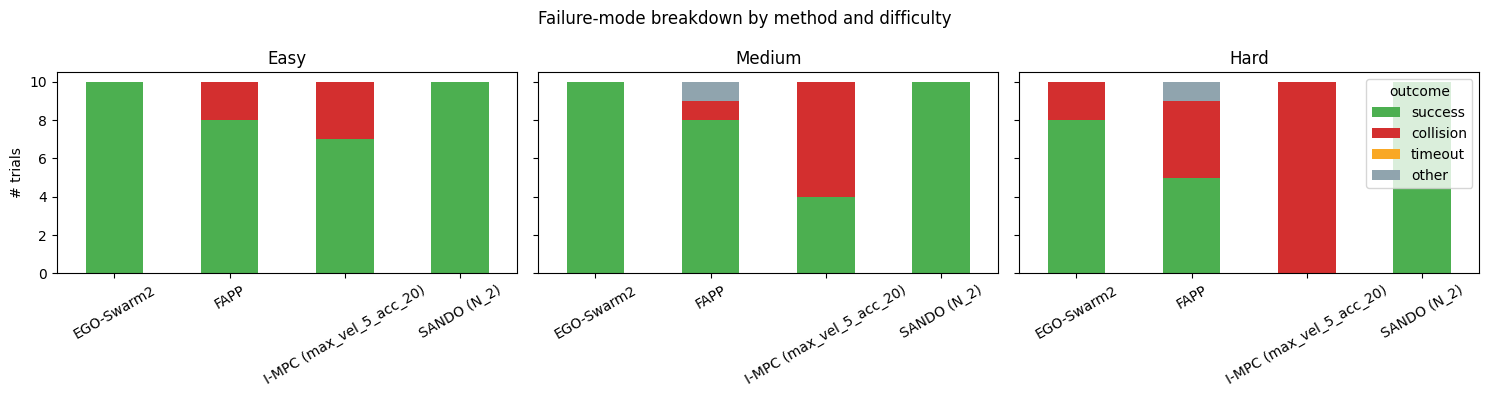

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
COLORS = {'success': '#4caf50', 'collision': '#d32f2f', 'timeout': '#f9a825', 'other': '#90a4ae'}

for ax, case in zip(axes, CASES):
    sub = outcome_table.xs(case, level='case')[OUTCOMES]
    sub.plot(kind='bar', stacked=True, ax=ax, color=[COLORS[o] for o in OUTCOMES], legend=(case == CASES[-1]))
    ax.set_title(f'{case.capitalize()}')
    ax.set_ylabel('# trials')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Failure-mode breakdown by method and difficulty')
plt.tight_layout()
plt.show()


## 6. Failure correlates: constraint violations, compute time, min distance

For each method, compare metric distributions between successful and failed trials
in the Hard case (where failures are most common). High constraint-violation counts in
failed trials → soft-constraint issue. High compute time in failed trials → reactivity issue.
Low min-distance-to-obstacles in failed trials → corridor / avoidance margin issue.

In [9]:
hard = trials[trials['case'] == 'hard'].copy()
hard['failed'] = hard['outcome'] != 'success'

metrics = ['vel_violation_count', 'acc_violation_count', 'jerk_violation_count',
           'opt_time_mean', 'min_distance_to_obstacles', 'collision_penetration_max',
           'collision_unique_obstacles']

for method in hard['method'].unique():
    sub = hard[hard['method'] == method]
    if sub['failed'].nunique() < 2:
        print(f'\n=== {method}: all {sub["outcome"].iloc[0]} (Hard) ===')
        continue
    print(f'\n=== {method} (Hard, n={len(sub)}) — success vs failure mean (median) ===')
    rows = []
    for m in metrics:
        if m not in sub.columns or sub[m].isna().all():
            continue
        ok = sub.loc[~sub['failed'], m].dropna()
        bad = sub.loc[sub['failed'], m].dropna()
        if len(ok) == 0 or len(bad) == 0:
            continue
        rows.append({
            'metric': m,
            'success_mean': ok.mean(),
            'success_med': ok.median(),
            'failed_mean': bad.mean(),
            'failed_med': bad.median(),
        })
    print(pd.DataFrame(rows).to_string(index=False))



=== FAPP (Hard, n=10) — success vs failure mean (median) ===
                    metric  success_mean  success_med  failed_mean  failed_med
       vel_violation_count     87.200000    84.000000   114.000000   40.000000
       acc_violation_count      0.000000     0.000000     0.000000    0.000000
      jerk_violation_count      0.000000     0.000000     0.200000    0.000000
             opt_time_mean      0.630240     0.644296     0.494977    0.574273
 min_distance_to_obstacles      0.122418     0.135290          inf    0.000000
 collision_penetration_max      0.000000     0.000000     0.000000    0.000000
collision_unique_obstacles      0.000000     0.000000     0.600000    1.000000

=== EGO-Swarm2 (Hard, n=10) — success vs failure mean (median) ===
                    metric  success_mean  success_med  failed_mean  failed_med
       vel_violation_count    151.125000   149.500000   281.500000  281.500000
       acc_violation_count      0.000000     0.000000     0.000000    0.000000
 

## 7. Collision-only deep-dive

For collision-failed trials, look at:
- How many obstacles were hit
- Max penetration depth
- Were dynamic limits violated in the trial (suggesting tracking-error-like behavior)
- Min distance to obstacles in the trial

In [10]:
coll = trials[trials['outcome'] == 'collision'].copy()
if len(coll):
    summary = (
        coll
        .groupby(['method', 'case'], observed=True)
        .agg(
            n_collisions=('outcome', 'size'),
            avg_obstacles_hit=('collision_unique_obstacles', 'mean'),
            max_penetration=('collision_penetration_max', 'max'),
            avg_vel_violations=('vel_violation_count', 'mean'),
            avg_acc_violations=('acc_violation_count', 'mean'),
            avg_jerk_violations=('jerk_violation_count', 'mean'),
            avg_min_dist=('min_distance_to_obstacles', 'mean'),
        )
        .round(3)
    )
    display(summary)
else:
    print('No collision-classified trials found.')


n_collisions  avg_obstacles_hit  max_penetration  avg_vel_violations  avg_acc_violations  avg_jerk_violations  avg_min_dist
method                   case                                                                                                                               
EGO-Swarm2               hard               2               1.00            0.000             281.500               0.000                2.000           0.0
FAPP                     easy               2               0.50            0.000             138.500               0.000                0.000           0.0
                         medium             1               0.00            0.000              53.000               0.000                0.000           0.0
                         hard               4               0.75            0.000             142.500               0.000                0.250           0.0
I-MPC (max_vel_5_acc_20) easy               3               1.00            0.123            2202.667             316.000             1465.333           0.0
                         medium             6               1.00            0.226            3002.333            1091.833             1475.167           0.0
                         hard              10               1.10            0.361            3886.000            2816.300             1096.400           0.0

## 8. Timeout deep-dive

Timeouts suggest the agent stopped or oscillated, often due to MIQP/solver failure or aggressive corridor inflation. Look at compute time and how far the agent got.

In [11]:
to_df = trials[trials['outcome'] == 'timeout'].copy()
if len(to_df):
    to_summary = (
        to_df
        .groupby(['method', 'case'], observed=True)
        .agg(
            n_timeouts=('outcome', 'size'),
            avg_opt_time=('opt_time_mean', 'mean'),
            avg_path_eff=('path_efficiency', 'mean'),
            avg_flight_time=('flight_travel_time', 'mean'),
        )
        .round(3)
    )
    display(to_summary)
else:
    print('No timeout-classified trials found.')


No timeout-classified trials found.


## 9. Per-method narrative (auto-generated talking points)

Convert the numbers above into one-paragraph attribution per baseline. Edit by hand before
pasting into the response.

In [12]:
def describe(method):
    sub = trials[trials['method'] == method]
    by_case = sub.groupby('case', observed=True)['outcome'].value_counts().unstack(fill_value=0)
    out = [f'### {method}']
    for c in CASES:
        if c not in by_case.index:
            continue
        row = by_case.loc[c]
        total = row.sum()
        succ = row.get('success', 0)
        coll = row.get('collision', 0)
        tout = row.get('timeout', 0)
        other = row.get('other', 0)
        parts = []
        if coll:
            parts.append(f'{coll} collision')
        if tout:
            parts.append(f'{tout} timeout')
        if other:
            parts.append(f'{other} other')
        breakdown = ', '.join(parts) if parts else 'no failures'
        out.append(f'- **{c.capitalize()}** ({succ}/{total} success): {breakdown}.')
    print('\n'.join(out))
    print()

for m in trials['method'].unique():
    describe(m)


### FAPP
- **Easy** (8/10 success): 2 collision.
- **Medium** (8/10 success): 1 collision, 1 other.
- **Hard** (5/10 success): 4 collision, 1 other.

### EGO-Swarm2
- **Easy** (10/10 success): no failures.
- **Medium** (10/10 success): no failures.
- **Hard** (8/10 success): 2 collision.

### I-MPC (max_vel_5_acc_20)
- **Easy** (7/10 success): 3 collision.
- **Medium** (4/10 success): 6 collision.
- **Hard** (0/10 success): 10 collision.

### SANDO (N_2)
- **Easy** (10/10 success): no failures.
- **Medium** (10/10 success): no failures.
- **Hard** (10/10 success): no failures.



## 10. Next steps (manual)

Use the tables above to write the response paragraph per baseline. Template:

> **<Method>**: <X/10 success in Hard>. Failures broke down as <C collisions, T timeouts>.
> In the collision-failed trials, <vel/acc violations were elevated relative to successful trials by Y%>,
> consistent with <design choice: soft constraints / fixed avoidance radius / closed-loop tracker dynamics>.
> In the timeout-failed trials, <opt-time was Z ms vs W ms in successes>, suggesting <reactivity issue>.

Concretely:
- **EGO-Swarm2** — soft-constraint optimizer; if collisions correlate with vel_violation_count being high, the soft-constraint hypothesis is supported.
- **FAPP** — fixed 1.4m avoidance radius; if collisions cluster on small dynamic cubes (look at `collision_unique_obstacles`), the fixed-radius hypothesis is supported.
- **I-MPC** — closed-loop high-fidelity tracker; if collisions correlate with high `vel/acc_violation_count` even at nominal limits, the tracker-error hypothesis is supported.
- **SANDO** — should show ~zero collisions and zero constraint violations; serves as the positive control.